In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import cv2
from IPython.core.pylabtools import figsize

from sklearn.model_selection import train_test_split
from tqdm import tqdm

Matplotlib is building the font cache; this may take a moment.


# Chargement des données

In [3]:
data_path = './Human-Segmentation-Dataset-master/train.csv'
df = pd.read_csv(data_path)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


# Exploration des données

In [41]:
sample = df.iloc[np.random.randint(0, df.shape[0], size=5)]
print(sample)

def generate_sample_ims(sample):
    imgs = sample.images
    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, image in enumerate(imgs):
        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax[i].set_title('image')
        ax[i].imshow(image)
def generate_sample_masks(sample):
    masks = sample.masks
    _, ax = plt.subplots(1, 5, figsize=(15,3))
    ax = ax.flatten()

    for i, mask in enumerate(masks):
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE) / 255.0

        ax[i].set_title('mask')
        ax[i].imshow(mask, cmap='gray')

                                                 masks  \
178  Human-Segmentation-Dataset-master/Ground_Truth...   
187  Human-Segmentation-Dataset-master/Ground_Truth...   
29   Human-Segmentation-Dataset-master/Ground_Truth...   
3    Human-Segmentation-Dataset-master/Ground_Truth...   
180  Human-Segmentation-Dataset-master/Ground_Truth...   

                                                images  
178  Human-Segmentation-Dataset-master/Training_Ima...  
187  Human-Segmentation-Dataset-master/Training_Ima...  
29   Human-Segmentation-Dataset-master/Training_Ima...  
3    Human-Segmentation-Dataset-master/Training_Ima...  
180  Human-Segmentation-Dataset-master/Training_Ima...  


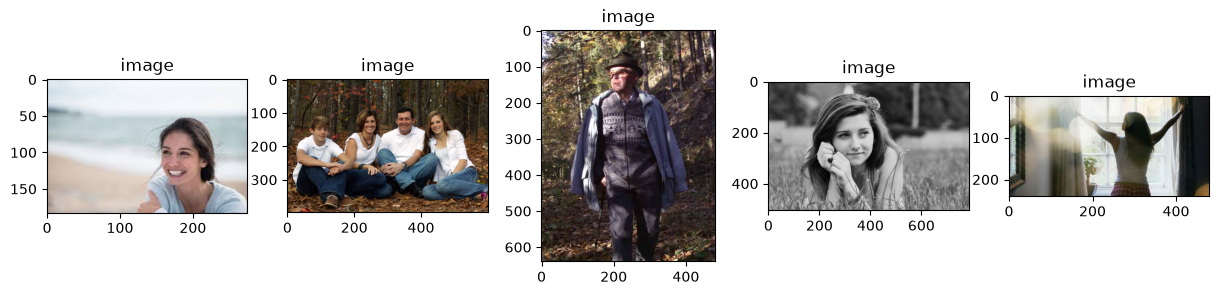

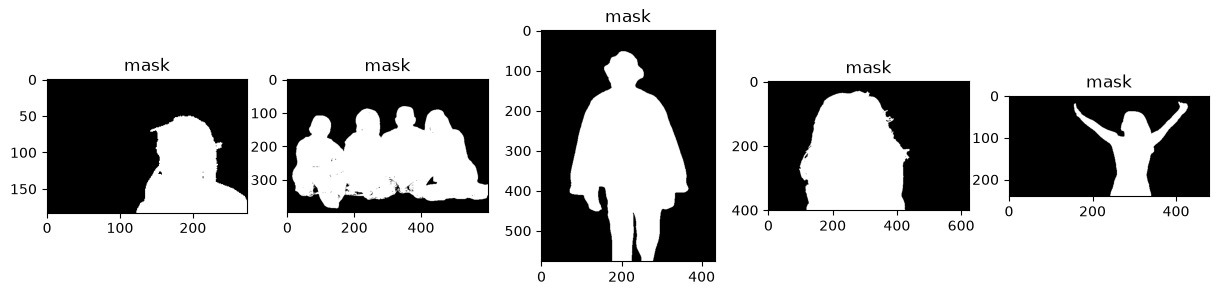

In [42]:
generate_sample_ims(sample)
generate_sample_masks(sample)

# Data SPLIT

In [43]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

# modifications des images

In [44]:
import albumentations as A

def get_train_augs():
    return A.Compose([
        A.Resize(320, 320),
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
    ], is_check_shapes=False)

def get_val_augs():
    return A.Compose([
        A.Resize(320, 320),
    ], is_check_shapes=False)

/Users/nini/MLPCNNPYTORCH/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [45]:
from torch.utils.data import Dataset

récupère image + mask au besoin

In [46]:
class SegmentationDataset(Dataset):
    def __init__(self, df, augs):
        self.df = df
        self.augs = augs

    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        sample = self.df.iloc[idx]
        image = sample.images
        mask = sample.masks

        image = cv2.imread(image)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask, cv2.IMREAD_GRAYSCALE)
        mask = np.expand_dims(mask, axis=-1)



In [47]:
train_data = SegmentationDataset(train_df, get_train_augs())
val_data = SegmentationDataset(val_df, get_val_augs())

In [48]:
def processed_image(idx):
    image, mask = train_data[idx]

    plt.subplot(1,2,1)
    plt.imshow(np.transpose(image, (1,2,0)))
    plt.axis('off')
    plt.title("IMAGE");

    plt.subplot(1,2,2)
    plt.imshow(np.transpose(mask, (1,2,0)), cmap='gray')
    plt.axis('off')
    plt.title("GROUND TRUTH");
    plt.show()